In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [6]:
train.drop(['PassengerId','Cabin','Name','Ticket'], axis=1, inplace=True)
test.drop(['PassengerId','Cabin','Name','Ticket'], axis=1, inplace=True)

In [7]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [8]:
train = pd.get_dummies(train, columns=['Sex', 'Embarked'], drop_first=True)
test = pd.get_dummies(data=test, columns=['Sex', 'Embarked'],drop_first=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         714 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    uint8  
 7   Embarked_Q  891 non-null    uint8  
 8   Embarked_S  891 non-null    uint8  
dtypes: float64(2), int64(4), uint8(3)
memory usage: 44.5 KB


In [9]:
train['Sex_male'] = train['Sex_male'].astype(int)
train['Embarked_Q'] = train['Embarked_Q'].astype(int)
train['Embarked_S'] = train['Embarked_S'].astype(int)

test['Sex_male'] = test['Sex_male'].astype(int)
test['Embarked_Q'] = test['Embarked_Q'].astype(int)
test['Embarked_S'] = test['Embarked_S'].astype(int)

In [10]:
train['Family'] = train['SibSp'] + train['Parch']
test['Family'] = test['SibSp'] + test['Parch']

In [11]:
from sklearn.ensemble import RandomForestRegressor
age = train[['Age', 'Pclass', 'SibSp', 'Parch']]

know_age = age[age['Age'].notnull()].values
unknow_age = age[age['Age'].isnull()].values

X = know_age[:, 1:]
y = know_age[:, 0]

rf = RandomForestRegressor(random_state=0, n_estimators=1000, n_jobs=-1)
rf.fit(X,y)

predictAge = rf.predict(unknow_age[:, 1::])
train.loc[(train.Age.isnull()), 'Age'] = predictAge

In [12]:
from sklearn.ensemble import RandomForestRegressor
age = test[['Age', 'Pclass', 'SibSp', 'Parch']]

know_age = age[age['Age'].notnull()].values
unknow_age = age[age['Age'].isnull()].values

X = know_age[:, 1:]
y = know_age[:, 0]

rf = RandomForestRegressor(random_state=0, n_estimators=1000, n_jobs=-1)
rf.fit(X,y)

predictAge = rf.predict(unknow_age[:, 1::])
test.loc[(test.Age.isnull()), 'Age'] = predictAge

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    int64  
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
 9   Family      891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


In [14]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Age         418 non-null    float64
 2   SibSp       418 non-null    int64  
 3   Parch       418 non-null    int64  
 4   Fare        417 non-null    float64
 5   Sex_male    418 non-null    int64  
 6   Embarked_Q  418 non-null    int64  
 7   Embarked_S  418 non-null    int64  
 8   Family      418 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 29.5 KB


<AxesSubplot:xlabel='Fare', ylabel='Density'>

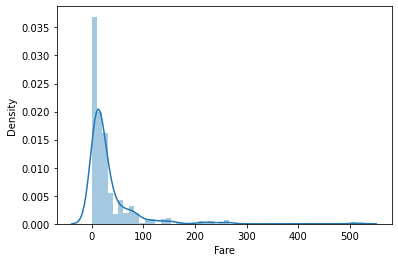

In [15]:
sns.distplot(train['Fare'])

In [16]:
train['Fare_range'] = np.nan
fare_range = [n * 50 for n in range(11)]
for idx, num in enumerate(fare_range):
    train.loc[train['Fare'] >= num, 'Fare_range'] = idx

In [17]:
test['Fare_range'] = np.nan
fare_range = [n * 50 for n in range(11)]
for idx, num in enumerate(fare_range):
    test.loc[test['Fare'] >= num, 'Fare_range'] = idx

In [18]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Family,Fare_range
0,0,3,22.0,1,0,7.2500,1,0,1,1,0.0
1,1,1,38.0,1,0,71.2833,0,0,0,1,1.0
2,1,3,26.0,0,0,7.9250,0,0,1,0,0.0
3,1,1,35.0,1,0,53.1000,0,0,1,1,1.0
4,0,3,35.0,0,0,8.0500,1,0,1,0,0.0


In [19]:
test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Family,Fare_range
0,3,34.5,0,0,7.8292,1,1,0,0,0.0
1,3,47.0,1,0,7.0000,0,0,1,1,0.0
2,2,62.0,0,0,9.6875,1,1,0,0,0.0
3,3,27.0,0,0,8.6625,1,0,1,0,0.0
4,3,22.0,1,1,12.2875,0,0,1,2,0.0


In [20]:
X_train = train.drop('Survived', axis=1)
y_train = train['Survived']
X_test = test.copy()

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, random_state=0, shuffle=True)

In [22]:
import lightgbm as lgb
categorical_features = ['Pclass', 'Sex_male', 'SibSp', 'Parch', 'Embarked_Q', 'Embarked_S']
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
lgb_eval = lgb.Dataset(X_valid, y_valid, reference=lgb_train,categorical_feature=categorical_features)

In [23]:
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
lgb_eval = lgb.Dataset(X_valid, y_valid, reference=lgb_train, categorical_feature=categorical_features)

params={
    'num_leaves':100,
    'objective':'binary',
    'max_depth':5,
    'learning_rate':.05,
    'early_stopping_rounds':15,
    'n_estimators':40000000
}
num_round=1000

In [24]:
model = lgb.train(params, lgb_train, valid_sets=[lgb_train, lgb_eval], num_boost_round=num_round, categorical_feature=categorical_features)

[LightGBM] [Info] Number of positive: 258, number of negative: 410
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 225
[LightGBM] [Info] Number of data points in the train set: 668, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.386228 -> initscore=-0.463198
[LightGBM] [Info] Start training from score -0.463198
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	training's binary_logloss: 0.644371	valid_1's binary_logloss: 0.641191
Training until validation scores don't improve for 15 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	training's binary_logloss: 0.623885	valid_1's binary_logloss: 0.621976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[3]	traini

In [25]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

In [26]:
sub = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
sub['Survived'] = list(map(int, y_pred))
sub.to_csv('submission.csv', index=False)